## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from tqdm import tqdm

from src.preproc import walsmart_preproc, walsmart_scaling
from src.modelling import *

In [2]:
raw_data = pd.read_csv('NOVAIMS_projectData_B2C_202526.csv')

## 2. Preprocessing

In [3]:
preproc_data = walsmart_preproc(raw_data)
scaled_data = walsmart_scaling(preproc_data)

## 3. Modelling

In [4]:
# Initialize cluster results container with ID_Client
# This will include the results from all clustering methods used
cluster_results = pd.DataFrame({
    'ID_Client': preproc_data['ID_Client'].reset_index(drop=True)
})

### 3.1. Removing noise

Original dimensions: 27
Reduced dimensions (PCA): 20
Explained variance ratio: 0.9543


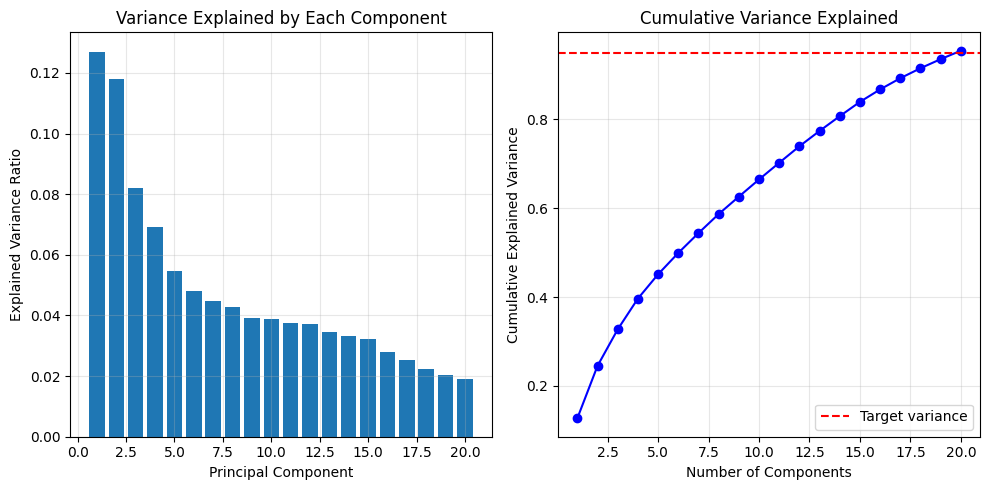

In [18]:
# Exclude ID_Client from PCA
scaled_data_no_id = scaled_data.drop(columns=['ID_Client'], errors='ignore')

# Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95)  # Keep 95% of variance
scaled_data_pca = pca.fit_transform(scaled_data_no_id)

print(f"Original dimensions: {scaled_data_no_id.shape[1]}")
print(f"Reduced dimensions (PCA): {scaled_data_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# Plot explained variance
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained by Each Component')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_.cumsum(), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance Explained')
plt.grid(alpha=0.3)
plt.axhline(y=0.95, color='r', linestyle='--', label='Target variance')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN on PCA-reduced data
# eps and min_samples can be tuned based on your data
dbscan = DBSCAN(eps=0.5, min_samples=5)
noise_labels = dbscan.fit_predict(scaled_data_pca)

# Identify noise points (label = -1)
noise_mask = noise_labels == -1
n_noise = noise_mask.sum()
n_total = len(noise_labels)
noise_percentage = (n_noise / n_total) * 100

print(f"DBSCAN Noise Detection Results (on PCA-reduced data):")
print(f"Total samples: {n_total}")
print(f"Noise points detected: {n_noise} ({noise_percentage:.2f}%)")
print(f"Core points: {n_total - n_noise} ({100 - noise_percentage:.2f}%)")

# Create cleaned dataset (remove noise)
scaled_data_clean = scaled_data[~noise_mask].reset_index(drop=True)
preproc_data_clean = preproc_data[~noise_mask].reset_index(drop=True)

print(f"\nCleaned dataset shape: {scaled_data_clean.shape}")
print(f"Removed {n_noise} rows due to noise detection")

DBSCAN Noise Detection Results (on PCA-reduced data):
Total samples: 122803
Noise points detected: 10084 (8.21%)
Core points: 112719 (91.79%)

Cleaned dataset shape: (112719, 28)
Removed 10084 rows due to noise detection


### 3.1. RFM/Value Clustering

In [7]:
# R: Recency_in_weeks (lower is better, so reverse the ranking)
# F: Frequency_items (higher is better)
# M: Total_Profit (higher is better)

r_score = pd.qcut(preproc_data['Recency_in_weeks'], q=3, labels=[1, 2, 3], duplicates='drop').reset_index(drop=True).astype(int)
f_score = pd.qcut(preproc_data['Frequency_items'], q=3, labels=[1, 2, 3], duplicates='drop').reset_index(drop=True).astype(int)
m_score = pd.qcut(preproc_data['Total_Profit'], q=3, labels=[1, 2, 3], duplicates='drop').reset_index(drop=True).astype(int)

rfm_segment = (r_score.astype(str) + f_score.astype(str) + m_score.astype(str))
cluster_results['RFM_Segment'] = rfm_segment

### 3.2. Buying Behaviour Segmentation

In [8]:
buying_behaviour_cols = ['Beer', 'Bottled_Water', 'Bread', 'Meat', 'Dairy', 'Fresh_Foods',
                        'Fruit_Beverages', 'Pastry', 'Sodas', 'Toiletries', 'Veggies', 
                        'Wines', 'Frozen_Foods','Promotional_percentage']
X_buying_behaviour = scaled_data[buying_behaviour_cols].copy()

# Faster elbow search: narrower K range and lighter k-means settings
inertias = []
silhouette_scores = []
K_range = range(2, 6)  # test 2–5 clusters

# Downsample for silhouette to speed up computation
silhouette_sample = X_buying_behaviour.sample(
    n=min(5000, len(X_buying_behaviour)), random_state=42
)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    kmeans.fit(X_buying_behaviour)
    inertias.append(kmeans.inertia_)

    # Use the same model to get labels on the sample for silhouette
    sample_labels = kmeans.predict(silhouette_sample)
    silhouette_scores.append(silhouette_score(silhouette_sample, sample_labels))

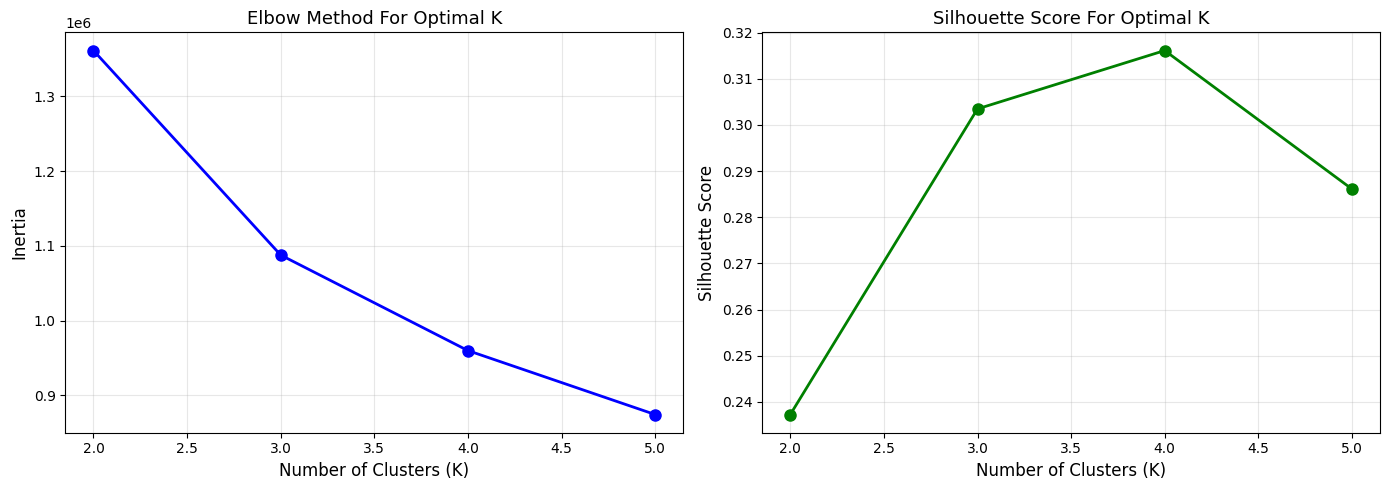


Optimal K:
K	Inertia		Silhouette Score
2	1361326.65		0.2372
3	1087617.30		0.3035
4	959789.38		0.3161
5	874202.34		0.2861

Best K by Silhouette Score: 4 (score: 0.3161)


In [ ]:
# Display metrics for optimal K selection
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method For Optimal K', fontsize=13)
ax1.grid(True, alpha=0.3)

# Silhouette score plot
ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score For Optimal K', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed metrics
print("\nOptimal K:")
print("K\tInertia\t\tSilhouette Score")
for k, inertia, silhouette in zip(K_range, inertias, silhouette_scores):
    print(f"{k}\t{inertia:.2f}\t\t{silhouette:.4f}")

# Find best K by silhouette score
best_k_silhouette = list(K_range)[np.argmax(silhouette_scores)]
print(f"\nBest K by Silhouette Score: {best_k_silhouette} (score: {max(silhouette_scores):.4f})")

In [10]:
# Use k=4 for buying behaviour segmentation (can be adjusted based on elbow/silhouette analysis)
optimal_k = 4
kmeans_buying = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
buying_behaviour_clusters = kmeans_buying.fit_predict(X_buying_behaviour)

# Add results to cluster_results
cluster_results['Buying_Behaviour_Segment'] = buying_behaviour_clusters

### 3.3. DBSCAN Optimized Clustering

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import umap
import hdbscan

# 0. Separate ID column and numeric data
def prepare_data(scaled_data, id_column="ID_Client"):
    ids = scaled_data[id_column].values
    X = scaled_data.drop(columns=[id_column]).values
    return ids, X

# 1. PCA dimensionality reduction
def apply_pca(X, n_components=0.95):
    """
    PCA with variance retention (e.g., 95%) or fixed number of components.
    """
    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X)
    print(f"PCA reduced dimensionality from {X.shape[1]} → {X_pca.shape[1]}")
    return X_pca, pca

# 2. UMAP nonlinear embedding
def apply_umap(X_pca, n_neighbors=30, min_dist=0.1, n_components=2):
    """
    UMAP projection to low-dimensional manifold.
    """
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        random_state=42
    )
    X_umap = reducer.fit_transform(X_pca)
    print(f"UMAP reduced dimensionality to {n_components} components")
    return X_umap, reducer


# 3. HDBSCAN clustering
def apply_hdbscan(X_umap, min_cluster_size=30, min_samples=None):
    """
    Density-based clustering on UMAP space.
    """
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_method='eom'
    )
    labels = clusterer.fit_predict(X_umap)
    probs = clusterer.probabilities_
    print(f"HDBSCAN found {len(set(labels)) - (1 if -1 in labels else 0)} clusters")
    return labels, probs, clusterer


# 4. Full pipeline: PCA → UMAP → HDBSCAN

def pca_umap_hdbscan_pipeline(
    scaled_data,
    id_column="ID_Client",
    pca_components=0.95,
    umap_neighbors = 100,
    umap_min_dist = 0.5,
    umap_components = 2,
    hdbscan_min_cluster_size = 300,
    hdbscan_min_samples = 50
):
    '''
    Full pipeline: PCA → UMAP → HDBSCAN
    Manually optimized by changing parameters
    '''
    # Prepare data
    ids, X = prepare_data(scaled_data, id_column)

    # PCA
    X_pca, pca_model = apply_pca(X, n_components=pca_components)

    # UMAP
    X_umap, umap_model = apply_umap(
        X_pca,
        n_neighbors=umap_neighbors,
        min_dist=umap_min_dist,
        n_components=umap_components
    )

    # HDBSCAN
    labels, probs, hdbscan_model = apply_hdbscan(
        X_umap,
        min_cluster_size=hdbscan_min_cluster_size,
        min_samples=hdbscan_min_samples
    )

    # Build result dataframe
    result = pd.DataFrame({
        id_column: ids,
        "Cluster_HDBSCAN": labels,
        "Cluster_Probability": probs
    })

    return result, X_pca, X_umap, pca_model, umap_model, hdbscan_model

c:\Users\msard\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
result_df, X_pca, X_umap, pca_model, umap_model, hdbscan_model = pca_umap_hdbscan_pipeline(scaled_data)

cluster_results = cluster_results.merge(
    result_df[["ID_Client", "Cluster_HDBSCAN", "Cluster_Probability"]],
    on="ID_Client",
    how="left"
)
cluster_results.head()

PCA reduced dimensionality from 27 → 20


c:\Users\msard\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP reduced dimensionality to 2 components
HDBSCAN found 48 clusters


,ID_Client,Cluster_HDBSCAN,Cluster_Probability
0,10156431SEG17NKID781,46,0.805196
1,9056576FIA11NKID679,43,0.924092
2,9253304IST6NKID248,43,0.585780
3,9661067PER12NKID393,43,0.971607
4,9956825FEG11NKID326,30,1.000000


In [13]:
# Macro cLustering using these clusters
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

def compute_microcluster_centroids(X_umap, labels):
    """
    Computes centroids of each HDBSCAN micro-cluster in UMAP space.
    Noise (-1) is ignored.
    """
    unique_clusters = [c for c in np.unique(labels) if c != -1]
    centroids = []

    for c in unique_clusters:
        idx = np.where(labels == c)[0]
        centroid = X_umap[idx].mean(axis=0)
        centroids.append(centroid)

    return np.array(centroids), unique_clusters

def macro_cluster_centroids(centroids, n_macro_clusters=10):
    kmeans = KMeans(n_clusters=n_macro_clusters, random_state=42)
    macro_labels = kmeans.fit_predict(centroids)
    return macro_labels, kmeans

def assign_macro_clusters_to_customers(labels, unique_microclusters, macro_labels):
    """
    Map each customer to the macro-cluster of its micro-cluster.
    Noise points (-1) get macro label -1.
    """
    micro_to_macro = {micro: macro for micro, macro in zip(unique_microclusters, macro_labels)}

    macro_assignment = []
    for lbl in labels:
        if lbl == -1:
            macro_assignment.append(-1)
        else:
            macro_assignment.append(micro_to_macro[lbl])

    return np.array(macro_assignment)


def build_macrocluster_results(ids, micro_labels, macro_labels):
    return pd.DataFrame({
        "ID_Client": ids,
        "Micro_Cluster": micro_labels,
        "Macro_Cluster": macro_labels
    })

# Extract what we need
ids = result_df["ID_Client"].values
micro_labels = result_df["Cluster_HDBSCAN"].values

# 1. Compute centroids
centroids, unique_microclusters = compute_microcluster_centroids(X_umap, micro_labels)

# 2. Macro-cluster the centroids
macro_centroid_labels, macro_model = macro_cluster_centroids(centroids, n_macro_clusters=10)

# 3. Assign macro-clusters to customers
macro_assignments = assign_macro_clusters_to_customers(
    micro_labels,
    unique_microclusters,
    macro_centroid_labels
)

# 4. Build final dataframe
macro_df = build_macrocluster_results(ids, micro_labels, macro_assignments)

cluster_results = cluster_results.merge(
    macro_df[["ID_Client", "Micro_Cluster", "Macro_Cluster"]],
    on="ID_Client",
    how="left"
)

cluster_results.head()

,ID_Client,Cluster_HDBSCAN,Cluster_Probability,Micro_Cluster_x,Macro_Cluster_x,Micro_Cluster_y,Macro_Cluster_y,Micro_Cluster,Macro_Cluster
0,10156431SEG17NKID781,46,0.805196,46,0,46,0,46,0
1,9056576FIA11NKID679,43,0.924092,43,1,43,1,43,9
2,9253304IST6NKID248,43,0.585780,43,1,43,1,43,9
3,9661067PER12NKID393,43,0.971607,43,1,43,1,43,9
4,9956825FEG11NKID326,30,1.000000,30,2,30,2,30,2


## 4. Cluster Visualization

### 4.1 HDBSCAN macro clusters

In [17]:
# Merge macro clusters into preproc_data
viz_df = preproc_data.merge(
    macro_df[["ID_Client", "Macro_Cluster"]],
    on="ID_Client",
    how="left"
)

cluster_profiles = viz_df.groupby("Macro_Cluster").mean(numeric_only=True)
cluster_profiles.to_csv("cluster_profiles.csv", index=True)
cluster_profiles

,Frequency_items,Longevity_months,Recency_in_weeks,Flaged,Promotional_percentage,Beer,Bottled_Water,Bread,Meat,Dairy,...,Wines,ZIP_Missing,ZIP_8,ZIP_0,ZIP_4,ZIP_Others,Relevance_Priority,Has_Returns,Education_Years,Total_Profit
Macro_Cluster,,,,,,,,,,,,,,,,,,,,,
-1,39.441667,13.917391,10.206522,0.000000,19.961598,57.054348,49.987319,31.318841,5.578261,64.026087,...,25.131884,0.005072,0.393841,0.431884,0.169203,0.0,0.930435,0.019203,13.230435,540.678986
0,38.888758,16.055901,10.531059,0.000000,20.358508,62.178962,51.804851,43.537613,21.728057,58.831793,...,16.150395,0.000168,0.707612,0.268582,0.023637,0.0,0.815549,0.270935,12.256147,700.737053
1,38.850161,9.966486,11.938571,0.000000,11.833185,45.024860,44.569574,29.666723,0.367300,31.200492,...,7.129900,0.000000,0.000000,1.000000,0.000000,0.0,1.000000,0.000000,14.263957,537.831478
2,37.209677,15.217405,11.103091,0.000000,10.853834,45.165522,44.820434,20.803631,0.530234,80.796087,...,22.524654,0.000000,0.999939,0.000061,0.000000,0.0,1.000000,0.000000,13.279038,427.753097
3,38.026840,17.699541,11.147864,0.000000,8.468668,73.871253,73.611248,28.701328,0.578952,34.999324,...,17.482694,0.000000,0.767270,0.000483,0.232247,0.0,0.844557,0.000000,12.187111,509.209520
4,39.178682,11.841196,11.812761,0.000000,11.590879,74.298272,73.872448,29.742945,0.433841,29.904187,...,15.905541,0.000000,0.000000,1.000000,0.000000,0.0,1.000000,0.000000,13.329091,512.033472
5,38.001633,14.031020,11.279184,0.001633,12.101853,57.475918,56.749388,27.840816,1.177143,45.353469,...,15.309388,1.000000,0.000000,0.000000,0.000000,0.0,0.957551,0.035102,13.231837,507.210612
6,41.699362,16.275917,9.014354,1.000000,0.000000,90.155502,71.473684,61.106858,72.207337,91.602073,...,24.124402,0.007974,0.799841,0.138756,0.053429,0.0,0.212919,0.404306,12.000000,1316.640032
7,36.750993,12.976325,11.117592,0.000000,11.966302,56.819911,56.593402,29.892113,0.466742,31.187344,...,10.865056,0.000000,1.000000,0.000000,0.000000,0.0,1.000000,0.000000,14.214940,532.522170


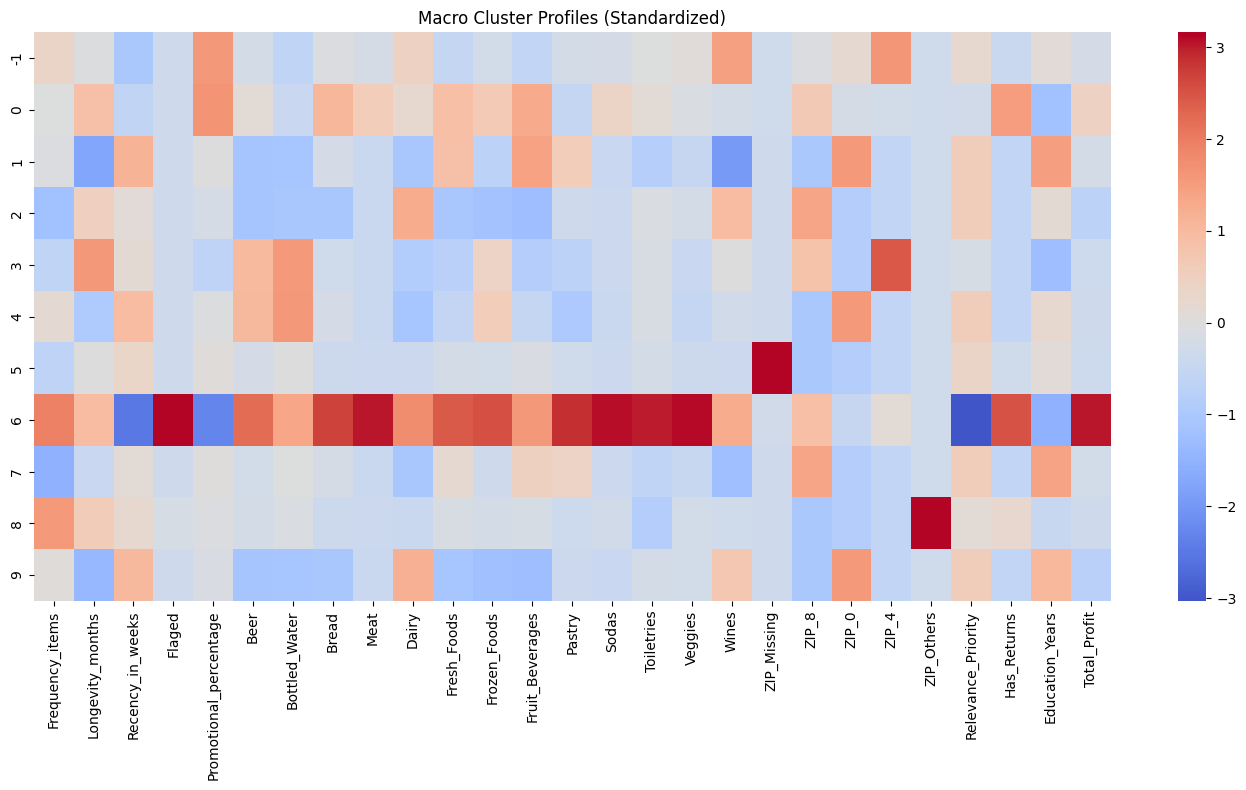

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Standardize the profiles for visualization
scaler = StandardScaler()
profiles_scaled = scaler.fit_transform(cluster_profiles)

plt.figure(figsize=(14, 8))
sns.heatmap(
    profiles_scaled,
    cmap="coolwarm",
    xticklabels=cluster_profiles.columns,
    yticklabels=cluster_profiles.index,
    center=0
)
plt.title("Macro Cluster Profiles (Standardized)")
plt.tight_layout()
plt.show()

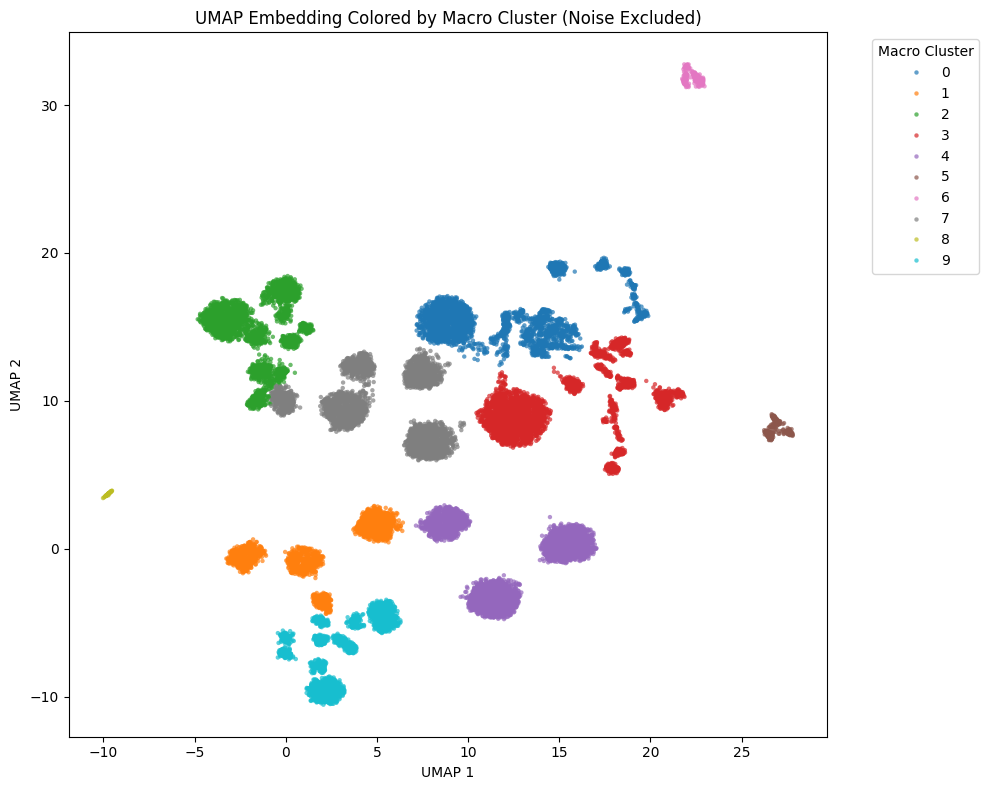

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Merge macro clusters with the data used for UMAP
# ---------------------------------------------------------

viz_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "ID_Client": scaled_data["ID_Client"].values
})

viz_umap = viz_umap.merge(
    macro_df[["ID_Client", "Macro_Cluster"]],
    on="ID_Client",
    how="left"
)

# ---------------------------------------------------------
# 2. Exclude noise cluster (-1)
# ---------------------------------------------------------

viz_umap = viz_umap[viz_umap["Macro_Cluster"] != -1]

# ---------------------------------------------------------
# 3. Optional: sample for speed (UMAP plots can be heavy)
# ---------------------------------------------------------

if len(viz_umap) > 20000:
    viz_umap = viz_umap.sample(20000, random_state=42)

# ---------------------------------------------------------
# 4. Plot UMAP colored by macro cluster
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=viz_umap,
    x="UMAP1",
    y="UMAP2",
    hue="Macro_Cluster",
    palette="tab10",
    s=10,
    alpha=0.7,
    linewidth=0
)

plt.title("UMAP Embedding Colored by Macro Cluster (Noise Excluded)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Macro Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4.2 Buying Behaviour Radar Charts

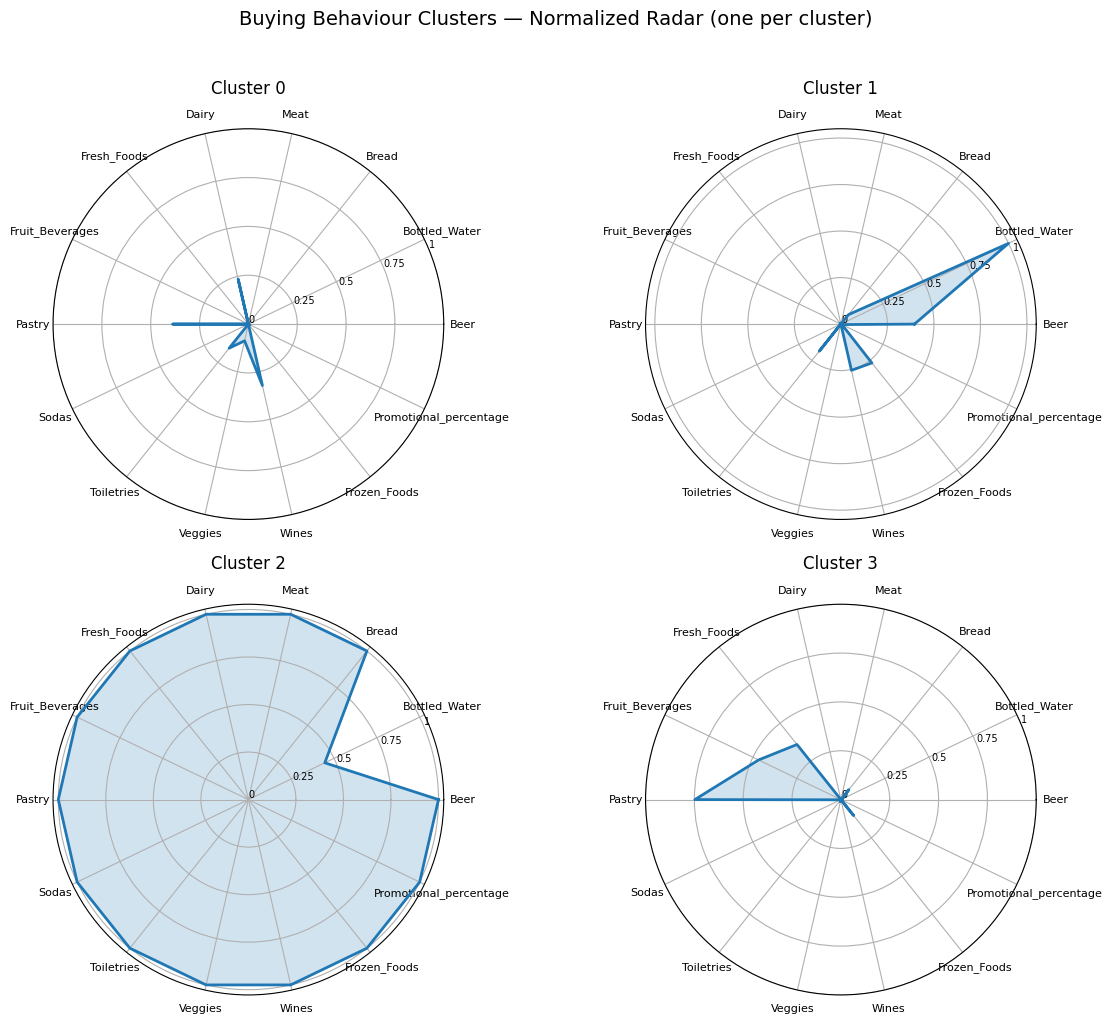

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure viz_df exists
if 'viz_df' not in globals():
    viz_df = preproc_data.merge(cluster_results, on='ID_Client', how='left')

product_cols = ['Beer', 'Bottled_Water', 'Bread', 'Meat', 'Dairy', 'Fresh_Foods',
                'Fruit_Beverages', 'Pastry', 'Sodas', 'Toiletries', 'Veggies', 'Wines',
                'Frozen_Foods', 'Promotional_percentage']

# Mean profile per cluster
cluster_means = viz_df.groupby('Buying_Behaviour_Segment')[product_cols].mean()

# Normalize features 0-1 across clusters to make shapes comparable
feature_min = cluster_means.min()
feature_max = cluster_means.max()
feature_range = (feature_max - feature_min).replace(0, 1)
means_norm = (cluster_means - feature_min) / feature_range

labels = product_cols
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate([angles, angles[:1]])

n_clusters = len(means_norm)
cols = 2
rows = int(np.ceil(n_clusters / cols))
fig = plt.figure(figsize=(cols * 6, rows * 5))

for idx, (cluster_id, row) in enumerate(means_norm.iterrows()):
    ax = plt.subplot(rows, cols, idx + 1, projection='polar')
    values = row.values
    values = np.concatenate([values, values[:1]])
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0", "0.25", "0.5", "0.75", "1"], fontsize=7)
    ax.set_title(f'Cluster {cluster_id}', fontsize=12, pad=12)

plt.suptitle('Buying Behaviour Clusters — Normalized Radar (one per cluster)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 RFM Radar Charts

In [12]:
import pandas as pd

# Ensure viz_df exists
if 'viz_df' not in globals():
    viz_df = preproc_data.merge(cluster_results, on='ID_Client', how='left')

# Get all numeric columns from preproc_data
numeric_cols = preproc_data.select_dtypes(include=['number']).columns.tolist()

# Remove ID_Client as it's not meaningful for profiling
if 'ID_Client' in numeric_cols:
    numeric_cols.remove('ID_Client')

# Remove Total_Profit
if 'Total_Profit' in numeric_cols:
    numeric_cols.remove('Total_Profit')

# Compute mean profile for each RFM segment
rfm_profiles = viz_df.groupby('RFM_Segment')[numeric_cols].mean().round(2)

# Save to CSV
rfm_profiles.to_csv('outputs/RFM_Cluster_Profiles.csv')

# Display as dataframe
rfm_profiles

,Frequency_items,Longevity_months,Recency_in_weeks,Flaged,Promotional_percentage,Beer,Bottled_Water,Bread,Meat,Dairy,...,Veggies,Wines,ZIP_Missing,ZIP_8,ZIP_0,ZIP_4,ZIP_Others,Relevance_Priority,Has_Returns,Education_Years
RFM_Segment,,,,,,,,,,,,,,,,,,,,,
111,24.45,13.44,7.35,0.00,11.02,52.27,52.03,22.10,0.72,61.44,...,15.55,13.47,0.01,0.62,0.31,0.05,0.00,0.95,0.02,13.36
112,24.59,13.73,7.28,0.00,11.61,64.73,64.40,29.36,0.89,38.73,...,20.54,17.69,0.01,0.64,0.30,0.05,0.00,0.95,0.02,13.33
113,24.47,14.26,6.38,0.03,15.17,76.94,57.42,53.96,34.32,65.14,...,52.89,26.77,0.01,0.67,0.25,0.07,0.00,0.93,0.09,12.99
121,37.75,13.41,7.52,0.00,11.59,52.10,51.63,22.08,0.59,61.62,...,16.36,13.78,0.01,0.50,0.44,0.05,0.00,0.94,0.03,13.33
122,37.77,13.37,7.39,0.01,11.44,64.16,63.66,29.35,0.79,39.26,...,20.80,17.79,0.01,0.52,0.42,0.04,0.00,0.94,0.03,13.30
123,37.92,14.06,6.61,0.03,14.64,67.80,57.51,43.40,21.49,55.29,...,37.21,17.70,0.01,0.61,0.33,0.05,0.00,0.92,0.09,12.98
131,53.90,14.57,7.44,0.00,11.48,51.72,51.65,21.93,0.62,62.03,...,16.30,13.29,0.01,0.54,0.40,0.05,0.00,0.95,0.03,13.13
132,53.86,14.53,7.35,0.01,11.87,64.34,63.93,29.39,0.93,39.41,...,21.25,17.87,0.01,0.57,0.37,0.05,0.00,0.95,0.03,13.09
133,54.25,14.84,6.52,0.05,14.22,68.42,59.17,47.75,26.13,66.35,...,41.60,18.26,0.01,0.67,0.28,0.04,0.00,0.91,0.11,12.80


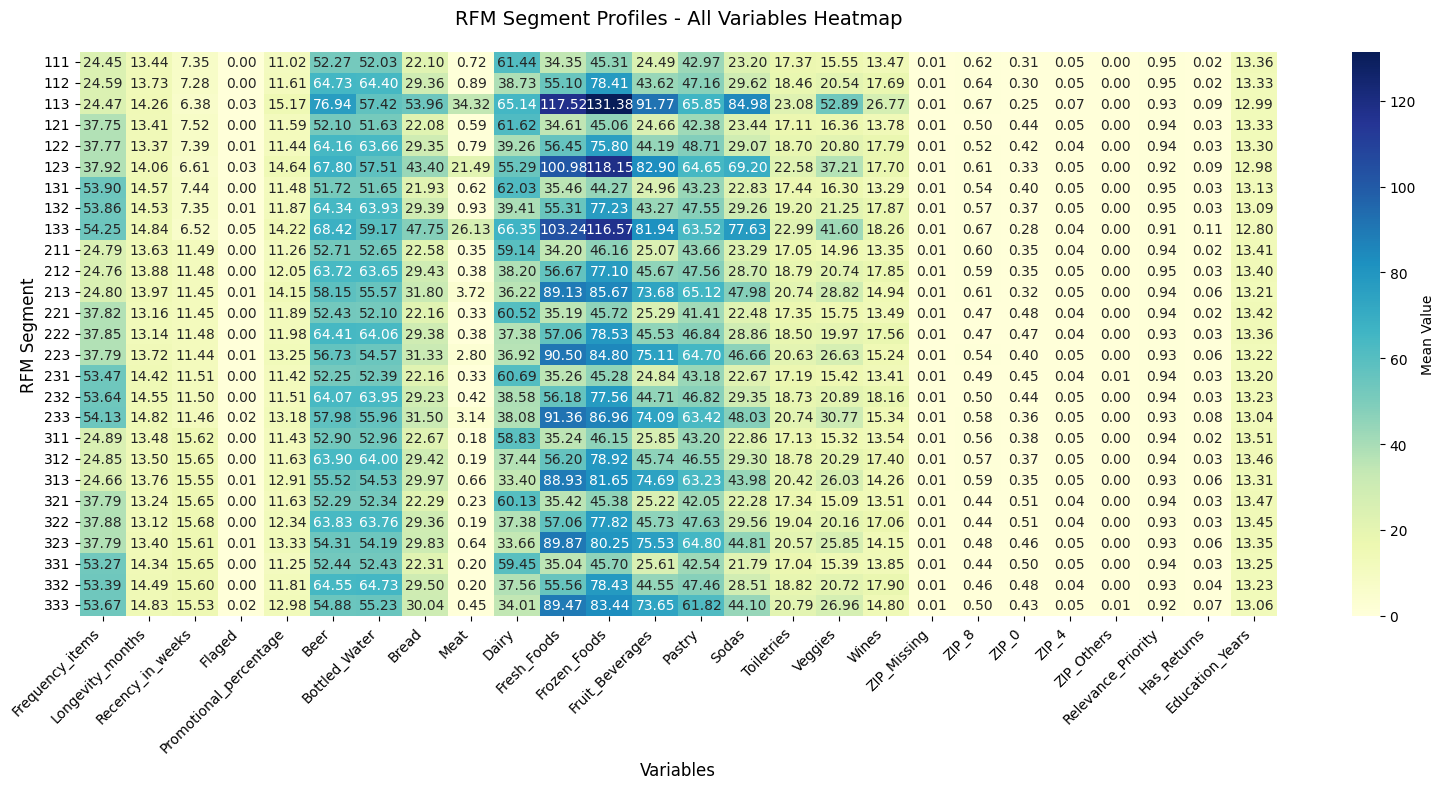

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create heatmap of RFM profiles
plt.figure(figsize=(16, 8))
sns.heatmap(rfm_profiles, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Mean Value'})
plt.title('RFM Segment Profiles - All Variables Heatmap', fontsize=14, pad=20)
plt.xlabel('Variables', fontsize=12)
plt.ylabel('RFM Segment', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

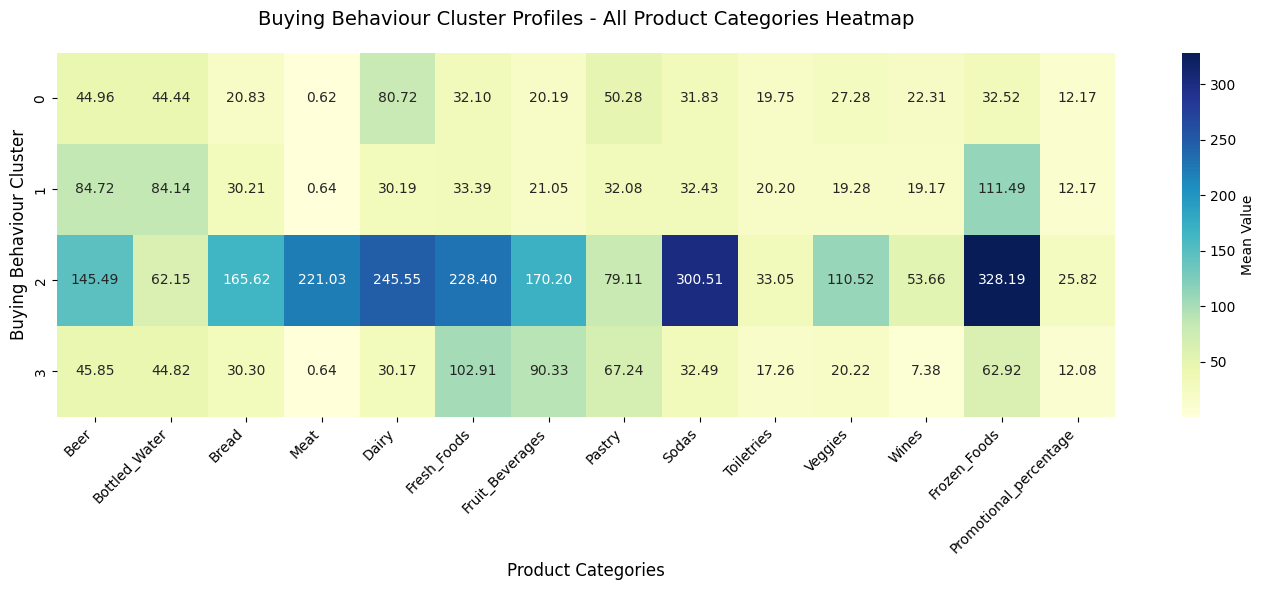

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure viz_df exists
if 'viz_df' not in globals():
    viz_df = preproc_data.merge(cluster_results, on='ID_Client', how='left')

product_cols = ['Beer', 'Bottled_Water', 'Bread', 'Meat', 'Dairy', 'Fresh_Foods',
                'Fruit_Beverages', 'Pastry', 'Sodas', 'Toiletries', 'Veggies', 'Wines',
                'Frozen_Foods', 'Promotional_percentage']

# Compute mean profile for each buying behaviour cluster
buying_behaviour_profiles = viz_df.groupby('Buying_Behaviour_Segment')[product_cols].mean().round(2)

# Create heatmap of buying behaviour profiles
plt.figure(figsize=(14, 6))
sns.heatmap(buying_behaviour_profiles, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Mean Value'})
plt.title('Buying Behaviour Cluster Profiles - All Product Categories Heatmap', fontsize=14, pad=20)
plt.xlabel('Product Categories', fontsize=12)
plt.ylabel('Buying Behaviour Cluster', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()